In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Cleaned Data

In [2]:
# Load the cleaned dataset
df = pd.read_csv('dataset/cleaned_job_data.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset Shape: (21865, 21)

Columns: ['jobid', 'company', 'jobtitle', 'jobdescription', 'industry', 'job_category', 'skills', 'skills_list', 'skills_count', 'education', 'experience', 'min_experience', 'max_experience', 'experience_level', 'joblocation_address', 'primary_location', 'payrate', 'postdate', 'post_year', 'post_month', 'numberofpositions']


,jobid,company,jobtitle,jobdescription,industry,job_category,skills,skills_list,skills_count,education,...,min_experience,max_experience,experience_level,joblocation_address,primary_location,payrate,postdate,post_year,post_month,numberofpositions
0,210516002263,MM Media Pvt Ltd,Walkin Data Entry Operator (night Shift),Job Description Send me Jobs like this Qualifi...,Media / Entertainment / Internet,Other,ITES,['ites'],1,UG: B.Tech/B.E. - Any Specialization PG:Any Po...,...,0,1,Entry Level (0-3 yrs),Chennai,Chennai,"1,50,000 - 2,25,000 P.A",2016-05-21 19:30:00+00:00,2016.0,5.0,NaN
1,210516002391,find live infotech,Work Based Onhome Based Part Time.,Job Description Send me Jobs like this Qualifi...,Advertising / PR / MR / Event Management,Other,Marketing,['marketing'],1,UG: B.Tech/B.E. - Any Specialization PG:MBA/PG...,...,0,0,Fresher,Chennai,Chennai,"1,50,000 - 2,50,000 P.A. 20000",2016-05-21 19:30:00+00:00,2016.0,5.0,60.0
2,101016900534,Softtech Career Infosystem Pvt. Ltd,Pl/sql Developer - SQL,Job Description Send me Jobs like this - as a ...,IT-Software / Software Services,IT & Software,IT Software - Application Programming,['it software - application programming'],1,UG: Any Graduate - Any Specialization PG:Any P...,...,4,8,Mid Level (3-7 yrs),Bengaluru,Bengaluru,Not Disclosed by Recruiter,2016-10-13 16:20:55+00:00,2016.0,10.0,NaN
3,81016900536,Onboard HRServices LLP,Manager/ad/partner - Indirect Tax - CA,Job Description Send me Jobs like this - Invol...,Banking / Financial Services / Broking,Banking & Finance,Accounts,['accounts'],1,UG: Any Graduate - Any Specialization PG:CA Do...,...,11,15,Expert Level (12+ yrs),"Mumbai, Bengaluru, Kolkata, Chennai, Coimbator...",Mumbai,Not Disclosed by Recruiter,2016-10-13 16:20:55+00:00,2016.0,10.0,NaN
4,120916002122,Spire Technologies and Solutions Pvt. Ltd.,JAVA Technical Lead (6-8 yrs) -,Job Description Send me Jobs like this Please ...,IT-Software / Software Services,IT & Software,IT Software - Application Programming,['it software - application programming'],1,UG: B.Tech/B.E. - Any Specialization PG:Any Po...,...,6,8,Senior Level (7-12 yrs),Bengaluru,Bengaluru,Not Disclosed by Recruiter,2016-10-13 16:20:55+00:00,2016.0,10.0,4.0


## 2. Prepare Features for Model Training

In [3]:
# Combine relevant text fields for feature extraction
def create_job_text(row):
    """Combine job description, title, and skills into single text"""
    parts = []
    
    if pd.notna(row['jobtitle']):
        parts.append(str(row['jobtitle']))
    
    if pd.notna(row['jobdescription']):
        parts.append(str(row['jobdescription']))
    
    if pd.notna(row['skills']):
        parts.append(str(row['skills']))
    
    return ' '.join(parts).lower()

df['combined_text'] = df.apply(create_job_text, axis=1)
print(f"✓ Created combined text feature")
print(f"Sample text length: {df['combined_text'].str.len().mean():.0f} characters")

✓ Created combined text feature
Sample text length: 2037 characters


## 3. Text Vectorization using TF-IDF

In [5]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english'
)

# Fit and transform the text data
print("Vectorizing job descriptions...")
X_tfidf = tfidf_vectorizer.fit_transform(df['combined_text'])

print(f"✓ TF-IDF matrix shape: {X_tfidf.shape}")
print(f"✓ Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

# Save the vectorizer for later use
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✓ Vectorizer saved to models/tfidf_vectorizer.pkl")

Vectorizing job descriptions...
✓ TF-IDF matrix shape: (21865, 5000)
✓ Number of features: 5000
✓ Vectorizer saved to models/tfidf_vectorizer.pkl


In [6]:
# Display top TF-IDF features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 20 TF-IDF features:")
print(feature_names[:20])


Top 20 TF-IDF features:
['00' '00 000' '00 pm' '000' '000 00' '000 12' '000 25' '000 50' '000 75'
 '000 best' '000 employees' '000 industry' '000 people'
 '000 qualification' '01' '02' '02 16' '03' '03 information20sheet' '05']


## 4. Prepare Labels for Classification

Target classes: ['Banking & Finance' 'IT & Software' 'Other' 'Pharma & Healthcare'
 'Retail & Ecommerce']
Number of classes: 5
✓ Label encoder saved


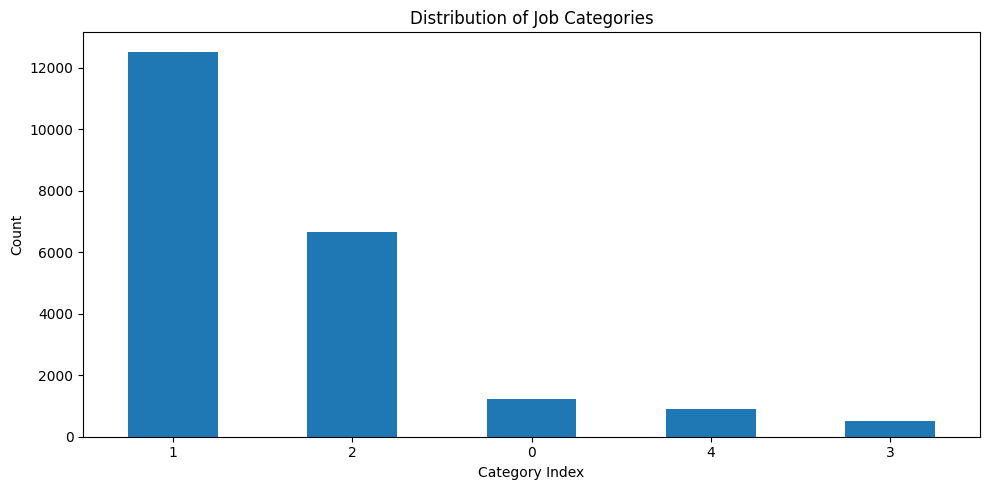

In [7]:
# Use job_category as target variable for classification
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['job_category'])

print(f"Target classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

# Save label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✓ Label encoder saved")

# Display class distribution
plt.figure(figsize=(10, 5))
pd.Series(y).value_counts().plot(kind='bar')
plt.title('Distribution of Job Categories')
plt.xlabel('Category Index')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Split Data for Training and Testing

In [8]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature dimensions: {X_train.shape[1]}")

Training set size: 17492
Test set size: 4373
Feature dimensions: 5000


## 6. Train Multiple Models

### 6.1 Random Forest Classifier

In [9]:
# Train Random Forest model
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"✓ Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=label_encoder.classes_))

Training Random Forest Classifier...
✓ Random Forest Accuracy: 0.9774

Classification Report:
                     precision    recall  f1-score   support

  Banking & Finance       1.00      0.99      1.00       246
      IT & Software       0.99      0.97      0.98      2505
              Other       0.95      0.98      0.97      1335
Pharma & Healthcare       1.00      1.00      1.00       104
 Retail & Ecommerce       1.00      0.96      0.98       183

           accuracy                           0.98      4373
          macro avg       0.99      0.98      0.98      4373
       weighted avg       0.98      0.98      0.98      4373



### 6.2 Gradient Boosting Classifier

In [10]:
# Train Gradient Boosting model
print("Training Gradient Boosting Classifier...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_predictions)

print(f"✓ Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_predictions, target_names=label_encoder.classes_))

Training Gradient Boosting Classifier...
✓ Gradient Boosting Accuracy: 0.9966

Classification Report:
                     precision    recall  f1-score   support

  Banking & Finance       1.00      0.99      1.00       246
      IT & Software       1.00      1.00      1.00      2505
              Other       0.99      0.99      0.99      1335
Pharma & Healthcare       1.00      1.00      1.00       104
 Retail & Ecommerce       1.00      1.00      1.00       183

           accuracy                           1.00      4373
          macro avg       1.00      1.00      1.00      4373
       weighted avg       1.00      1.00      1.00      4373



### 6.3 Logistic Regression

In [11]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"✓ Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions, target_names=label_encoder.classes_))

Training Logistic Regression...
✓ Logistic Regression Accuracy: 0.9648

Classification Report:
                     precision    recall  f1-score   support

  Banking & Finance       0.97      0.91      0.94       246
      IT & Software       0.97      0.99      0.98      2505
              Other       0.95      0.96      0.96      1335
Pharma & Healthcare       0.99      0.88      0.93       104
 Retail & Ecommerce       0.99      0.84      0.91       183

           accuracy                           0.96      4373
          macro avg       0.97      0.91      0.94      4373
       weighted avg       0.97      0.96      0.96      4373



## 7. Model Comparison


Model Comparison:
                 Model  Accuracy
1    Gradient Boosting  0.996570
0        Random Forest  0.977361
2  Logistic Regression  0.964784


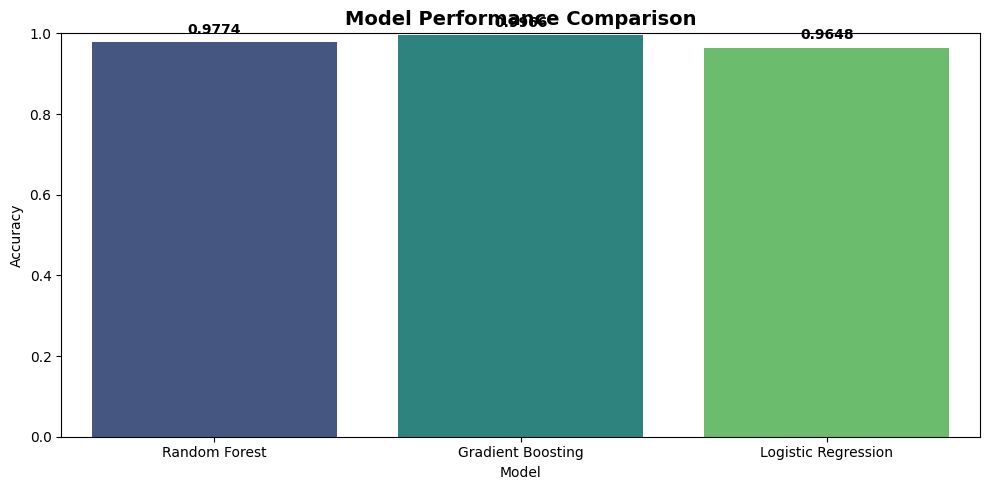

In [12]:
# Compare model performances
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Logistic Regression'],
    'Accuracy': [rf_accuracy, gb_accuracy, lr_accuracy]
})

print("\nModel Comparison:")
print(model_comparison.sort_values('Accuracy', ascending=False))

# Visualize comparison
plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(model_comparison['Accuracy']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Select Best Model and Save

In [13]:
# Select the best model based on accuracy
best_model_idx = model_comparison['Accuracy'].idxmax()
best_model_name = model_comparison.loc[best_model_idx, 'Model']
best_accuracy = model_comparison.loc[best_model_idx, 'Accuracy']

if best_model_name == 'Random Forest':
    best_model = rf_model
elif best_model_name == 'Gradient Boosting':
    best_model = gb_model
else:
    best_model = lr_model

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")

# Save the best model
with open('models/job_matcher_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("\n✓ Best model saved to models/job_matcher_model.pkl")

Best Model: Gradient Boosting
Best Accuracy: 0.9966

✓ Best model saved to models/job_matcher_model.pkl


## 9. Confusion Matrix

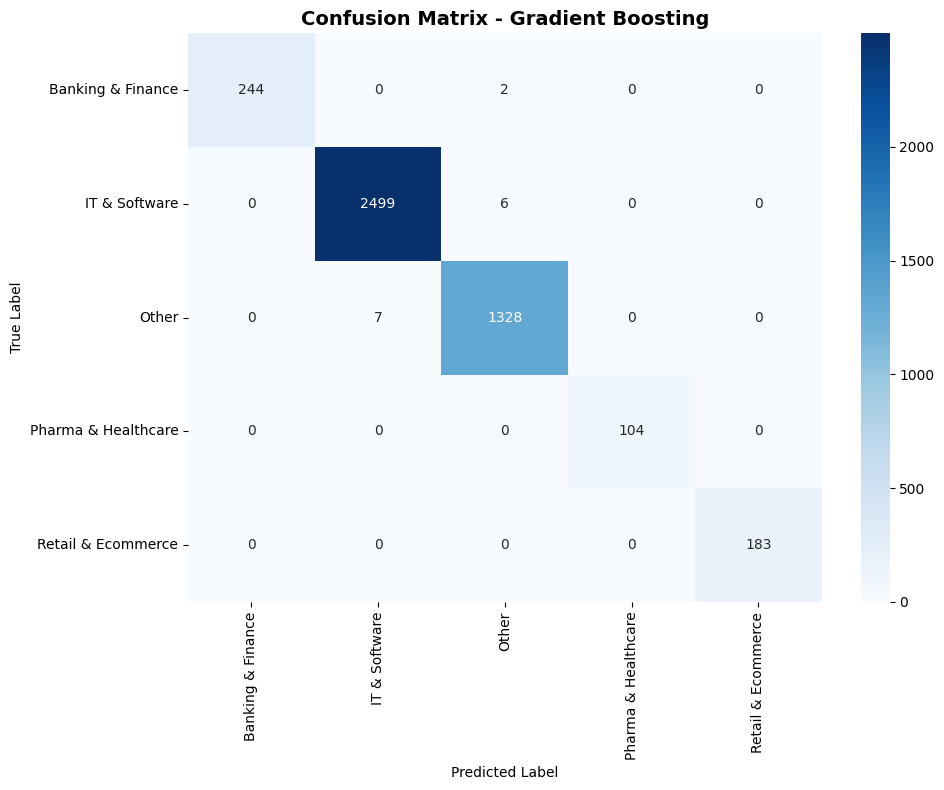

In [14]:
# Generate confusion matrix for best model
best_predictions = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_predictions)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 10. Build Similarity-Based Matching System

In [15]:
# Create a job matching system based on cosine similarity
class JobMatcher:
    def __init__(self, vectorizer, job_data):
        self.vectorizer = vectorizer
        self.job_data = job_data
        self.job_vectors = vectorizer.transform(job_data['combined_text'])
    
    def find_matching_jobs(self, resume_text, top_k=10):
        """Find top matching jobs for a resume"""
        # Vectorize resume text
        resume_vector = self.vectorizer.transform([resume_text])
        
        # Calculate cosine similarity
        similarities = cosine_similarity(resume_vector, self.job_vectors)[0]
        
        # Get top k indices
        top_indices = similarities.argsort()[-top_k:][::-1]
        
        # Create results dataframe
        results = self.job_data.iloc[top_indices].copy()
        results['similarity_score'] = similarities[top_indices]
        results['match_percentage'] = (similarities[top_indices] * 100).round(2)
        
        return results[['jobtitle', 'company', 'job_category', 'primary_location', 
                       'experience', 'skills', 'match_percentage']]

# Initialize matcher
job_matcher = JobMatcher(tfidf_vectorizer, df)
print("✓ Job matcher initialized")

# Save the matcher
with open('models/job_matcher.pkl', 'wb') as f:
    pickle.dump(job_matcher, f)
print("✓ Job matcher saved")

✓ Job matcher initialized
✓ Job matcher saved


## 11. Test the Matching System

In [16]:
# Test with a sample resume profile
sample_resume = """
Software Engineer with 5 years of experience in Python, Java, and JavaScript.
Strong background in web development using Django, Flask, React, and Node.js.
Experience with cloud platforms like AWS and Azure.
Excellent problem-solving skills and team collaboration.
Bachelor's degree in Computer Science.
Looking for senior developer roles in IT companies.
"""

print("Finding matching jobs for sample resume...\n")
matches = job_matcher.find_matching_jobs(sample_resume, top_k=10)

print("Top 10 Matching Jobs:")
print("="*100)
for idx, row in matches.iterrows():
    print(f"\n{row['match_percentage']}% Match - {row['jobtitle']}")
    print(f"Company: {row['company']}")
    print(f"Category: {row['job_category']}")
    print(f"Location: {row['primary_location']}")
    print(f"Experience: {row['experience']}")
    print("-"*100)

Finding matching jobs for sample resume...

Top 10 Matching Jobs:

39.19% Match - MEAN Stack Developer - Node.js/mongodb
Company: Readmind Info Services
Category: IT & Software
Location: Hyderabad
Experience: 4 - 7 yrs
----------------------------------------------------------------------------------------------------

34.15% Match - node js Developer
Company: Yuva ManPower Consultancy Pvt Ltd
Category: IT & Software
Location: Chennai
Experience: 2 - 4 yrs
----------------------------------------------------------------------------------------------------

31.53% Match - Node.js Developer
Company: Aten Info Solutions
Category: IT & Software
Location: Hyderabad
Experience: 2 - 7 yrs
----------------------------------------------------------------------------------------------------

29.9% Match - Startup - Node.js Developer
Company: Qulp
Category: Retail & Ecommerce
Location: Bengaluru/Bangalore
Experience: 2 - 4 yrs
----------------------------------------------------------------------

## 12. Save Model Metadata

In [17]:
# Save model metadata
metadata = {
    'model_type': best_model_name,
    'accuracy': float(best_accuracy),
    'num_classes': len(label_encoder.classes_),
    'classes': label_encoder.classes_.tolist(),
    'num_features': X_train.shape[1],
    'training_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
    'vectorizer_params': {
        'max_features': 5000,
        'min_df': 2,
        'max_df': 0.8,
        'ngram_range': (1, 2)
    }
}

import json
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Model metadata saved")
print("\nModel Metadata:")
print(json.dumps(metadata, indent=2))

✓ Model metadata saved

Model Metadata:
{
  "model_type": "Gradient Boosting",
  "accuracy": 0.9965698605076606,
  "num_classes": 5,
  "classes": [
    "Banking & Finance",
    "IT & Software",
    "Other",
    "Pharma & Healthcare",
    "Retail & Ecommerce"
  ],
  "num_features": 5000,
  "training_samples": 17492,
  "test_samples": 4373,
  "vectorizer_params": {
    "max_features": 5000,
    "min_df": 2,
    "max_df": 0.8,
    "ngram_range": [
      1,
      2
    ]
  }
}


## 13. Summary

In [ ]:
print("="*70)
print("MODEL TRAINING SUMMARY")
print("="*70)
print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Accuracy: {best_accuracy:.4f}")
print(f"✓ Number of Job Categories: {len(label_encoder.classes_)}")
print(f"✓ Number of Features: {X_train.shape[1]}")
print(f"✓ Training Samples: {X_train.shape[0]}")
print(f"✓ Test Samples: {X_test.shape[0]}")
print(f"\n📁 Saved Files:")
print(f"   - models/job_matcher_model.pkl (Best classifier)")
print(f"   - models/tfidf_vectorizer.pkl (TF-IDF vectorizer)")
print(f"   - models/label_encoder.pkl (Label encoder)")
print(f"   - models/job_matcher.pkl (Similarity-based matcher)")
print(f"   - models/model_metadata.json (Model information)")
print(f"\n🎯 Next Steps:")
print(f"   1. Use resume_parser.py to parse resumes with AI")
print(f"   2. Use job_predictor.py to match resumes with jobs")
print(f"   3. Run main.py for end-to-end resume analysis")
print("="*70)

MODEL TRAINING SUMMARY

✓ Best Model: Gradient Boosting
✓ Accuracy: 0.9966
✓ Number of Job Categories: 5
✓ Number of Features: 5000
✓ Training Samples: 17492
✓ Test Samples: 4373

📁 Saved Files:
   - models/job_matcher_model.pkl (Best classifier)
   - models/tfidf_vectorizer.pkl (TF-IDF vectorizer)
   - models/label_encoder.pkl (Label encoder)
   - models/job_matcher.pkl (Similarity-based matcher)
   - models/model_metadata.json (Model information)

🎯 Next Steps:
   1. Use resume_parser.py to parse resumes with AI
   2. Use job_predictor.py to match resumes with jobs
   3. Run main.py for end-to-end resume analysis


: 